# WEAT(Word Embedding Association Test)를 활용한 영화 장르 간 편향성 측정

본 프로젝트는 영화 시놉시스 코퍼스 데이터를 기반으로 단어 임베딩(Word Embedding) 알고리즘을 구축하고, 특정 대상(Target)과 속성(Attribute) 장르 간에 내재된 의미적 편향성을 WEAT 스코어를 통해 정량적으로 측정 및 시각화하는 것을 목적으로 한다.

## 목차 (Table of Contents)
- [STEP 0. 환경 설정 및 필수 라이브러리 임포트](#step-0)
- [STEP 1. 형태소 분석기를 이용한 코퍼스 명사 추출](#step-1)
- [STEP 2. 추출된 결과로 단어 임베딩 모델(Word2Vec) 구축](#step-2)
- [STEP 3. TF-IDF를 활용한 Target 및 Attribute 세부 단어 셋 구축](#step-3)
- [STEP 4. 전체 장르 간 WEAT Score 연산 및 Heatmap 시각화](#step-4)
- [STEP 5. 장르 간 편향성(WEAT Score) 최종 분석 및 모델 성능 비교 고찰](#step-5)
- [STEP 6. 프로젝트 회고 (Retrospective)](#step-6)


---

<br>

<a id="step-0"></a>
## STEP 0. 환경 설정 및 필수 라이브러리 임포트

프로젝트 전반에서 수행될 운영체제 경로 제어, 한국어 형태소 분석, 텍스트의 수치 벡터화, 선형 대수 연산 및 최종 통계 시각화를 위한 기본 라이브러리를 로드한다.


In [1]:
# 1. 파일 입출력 및 데이터 직렬화(백업) 관련 라이브러리
import os
import pickle

# 2. 선형 대수 연산 및 배열 제어 라이브러리
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 3. 통계 데이터 시각화 관련 라이브러리 및 환경 설정
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 출력 시 윈도우 한글 폰트('맑은 고딕') 적용 및 마이너스 부호 깨짐 현상 방지 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 4. 자연어 처리 및 텍스트 데이터 계량화 라이브러리
# 4-1. 한국어 토큰화 처리를 위한 형태소 분석기
from konlpy.tag import Okt

# 4-2. 단어 코퍼스를 벡터 공간에 투영하기 위한 워드임베딩 모델
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# 4-3. 형태소 기반 문서 내 단어 중요도(TF-IDF) 가중치 산출 도구
from sklearn.feature_extraction.text import TfidfVectorizer

print("프로젝트 수행을 위한 필수 라이브러리 임포트 및 시각화 환경 설정이 완료되었습니다.")


프로젝트 수행을 위한 필수 라이브러리 임포트 및 시각화 환경 설정이 완료되었습니다.


<a id="step-1"></a>
## STEP 1. 형태소 분석기를 이용한 코퍼스 명사 추출

텍스트 데이터에 내포된 핵심 개념과 의미적 편향성을 파악하기 위해, 문법적 요소(조사, 어미 등)를 제외하고 실질 형태소인 명사(Noun)만을 추출하는 전처리 작업을 수행한다. 
`Okt` 형태소 분석기를 활용하여 대상 문서를 형태소 단위로 분할 분석하며, 시스템 메모리 점유 및 연산 시간 소모를 고려하여 전처리가 완료된 데이터는 추후 학습을 위해 내장 디스크 단위에 직렬화(Serialize)하여 보관한다.


In [2]:
# 1-1. 단일 데이터 파일의 텍스트를 순회하며 명사를 추출하는 전처리 함수 정의

def read_token(file_name):
    """
    지정된 파일 경로에서 텍스트를 라인 단위로 읽어 형태소를 분석하고,
    품사가 명사(Noun)인 단어들만 공백으로 구분된 문자열 타입으로 반환한다.
    """
    okt = Okt()
    result = []
    
    # 텍스트 데이터의 워크스페이스 내 상대 경로 정의
    data_dir = "./weat/data"
    file_path = os.path.join(data_dir, file_name)
    
    # 윈도우 OS의 기본 인코딩(CP949) 연산에 따른 디코딩 에러를 방지하기 위해 utf-8 지정
    with open(file_path, 'r', encoding='utf-8') as fread:
        print(f"[{file_name}] 파일 전처리 작업 시작...")
        
        while True:
            line = fread.readline()
            if not line:
                break
            
            # Okt 분석 엔진을 통한 토큰화 (stem: 기본형 변환, norm: 정규화 적용)
            tokenlist = okt.pos(line, stem=True, norm=True)
            
            # 분리된 형태소 튜플 집합 내에서 명사 식별 및 수집
            for word in tokenlist:
                if word[1] in ["Noun"]:
                    result.append(word[0])
                    
    print(f"[{file_name}] 추출 종료. (총 명사 개수: {len(result)})")
    
    # 추출된 명사 리스트를 TF-IDF 및 추후 연산에 알맞은 시퀀스 문자열로 결합
    return ' '.join(result)


In [5]:
# 1-2. Target(예술/일반영화) 및 Attribute(전체 21개 장르) 코퍼스 전처리 수행

# Target 집단: 영화 구분에 따른 전처리 파싱
art = read_token('synopsis_art.txt')
gen = read_token('synopsis_gen.txt')

# Attribute 집단: 로컬 디렉토리 실제 파일명 포맷에 맞춘 21개 영문 장르명 배열 정의
genre_name = [
    'SF', 'family', 'show', 'horror', 'etc', 'documentary', 'drama', 'romance',
    'musical', 'mystery', 'crime', 'historical', 'western', 'adult', 'thriller',
    'animation', 'action', 'adventure', 'war', 'comedy', 'fantasy'
]

# 코퍼스 적재를 위한 속성(Attribute) 리스트 초기화
genre = []

# 지정된 21개 장르명 배열을 순회하며 개별 코퍼스 텍스트 파일 분석 처리
for genre_idx in genre_name:
    # 데이터 폴더 내 실제 영문 파일명(synopsis_장르명.txt) 규격 포맷팅
    synopsis_file = f"synopsis_{genre_idx}.txt"
    genre.append(read_token(synopsis_file))

print(f"✅ 총 {len(genre)}개 장르 파일에 대한 Tokenizing 추출 작업이 완료되었습니다.")


[synopsis_art.txt] 파일 전처리 작업 시작...
[synopsis_art.txt] 추출 종료. (총 명사 개수: 208471)
[synopsis_gen.txt] 파일 전처리 작업 시작...
[synopsis_gen.txt] 추출 종료. (총 명사 개수: 1008358)
[synopsis_SF.txt] 파일 전처리 작업 시작...
[synopsis_SF.txt] 추출 종료. (총 명사 개수: 21712)
[synopsis_family.txt] 파일 전처리 작업 시작...
[synopsis_family.txt] 추출 종료. (총 명사 개수: 8006)
[synopsis_show.txt] 파일 전처리 작업 시작...
[synopsis_show.txt] 추출 종료. (총 명사 개수: 7984)
[synopsis_horror.txt] 파일 전처리 작업 시작...
[synopsis_horror.txt] 추출 종료. (총 명사 개수: 57802)
[synopsis_etc.txt] 파일 전처리 작업 시작...
[synopsis_etc.txt] 추출 종료. (총 명사 개수: 49025)
[synopsis_documentary.txt] 파일 전처리 작업 시작...
[synopsis_documentary.txt] 추출 종료. (총 명사 개수: 156822)
[synopsis_drama.txt] 파일 전처리 작업 시작...
[synopsis_drama.txt] 추출 종료. (총 명사 개수: 377566)
[synopsis_romance.txt] 파일 전처리 작업 시작...
[synopsis_romance.txt] 추출 종료. (총 명사 개수: 102083)
[synopsis_musical.txt] 파일 전처리 작업 시작...
[synopsis_musical.txt] 추출 종료. (총 명사 개수: 3442)
[synopsis_mystery.txt] 파일 전처리 작업 시작...
[synopsis_mystery.txt] 추출 종료. (총 명사 개수: 15726)
[syno

In [6]:
# 1-2-1. 개별 타겟 및 장르(Attribute) 전처리 데이터에 대한 로컬 직렬화(백업)

import os
import pickle

# 백업 파일의 경로 및 포맷 규격 설정
backup_dir = "./weat/data"
os.makedirs(backup_dir, exist_ok=True)
genre_backup_path = os.path.join(backup_dir, "genre_corpus.pkl")

# 개별적으로 연산된 문자열 객체(art, gen)와 리스트 객체(genre)를 단일 딕셔너리 구조로 캡슐화
genre_data = {
    'art': art,
    'gen': gen,
    'genre': genre
}

# 파이썬 객체의 무결성을 유지하며 이진 모드로 로컬 디스크에 덤프(Dump)
with open(genre_backup_path, 'wb') as f:
    pickle.dump(genre_data, f)

print(f"개별 장르 문자열 코퍼스의 캐시 데이터가 안전하게 저장되었습니다. (경로: {genre_backup_path})")


개별 장르 문자열 코퍼스의 캐시 데이터가 안전하게 저장되었습니다. (경로: ./weat/data\genre_corpus.pkl)


In [ ]:
# 1-3. 전체 시놉시스(synopsis.txt) 전처리 알고리즘 및 이진 파일 직렬화 전체 흐름
# ※ 주의: 본 알고리즘은 단어 빈도수(TF-IDF)용 단일 문자열 반환 함수(read_token)와 달리,
# Word2Vec 학습 필수 규격인 '이중 문장 리스트(List of Lists)'를 유지하기 위해 독립적으로 수행합니다.


import os
import pickle
from konlpy.tag import Okt

# 1. 파일 시스템 경로 정의
data_dir = "./weat/data"
file_name = os.path.join(data_dir, "synopsis.txt")
backup_path = os.path.join(data_dir, "tokenized.pkl")

# 2. [과정 A] 초기 원본 텍스트 데이터의 스키마 및 형태 점검 (상위 5줄만 샘플링 출력)
print("--- [A] 원본 데이터 형태 점검 ---")
with open(file_name, 'r', encoding='utf-8') as file:
    for _ in range(5):
        print(file.readline().strip())
print("\n")

# 3. [과정 B] 형태소 제어기를 통한 명사(Noun) 코퍼스 추출 (리스트 보존)
print("--- [B] 전체 코퍼스의 명사 전처리 연산 돌입 (예상 소요 시간: 15~20분) ---")
okt = Okt()
tokenized = []

with open(file_name, 'r', encoding='utf-8') as file:
    while True:
        line = file.readline()
        if not line: break
        
        # 개별 문장을 형태소 단위로 분할 분석 후, 명사 요소만 수집하여 원본 라인(Sentence)을 훼손하지 않고 적재
        words = okt.pos(line, stem=True, norm=True)
        res = [w[0] for w in words if w[1] in ["Noun"]]
        tokenized.append(res)
        
print("명사 전처리 연산 구조화 완료.\n")

# 4. [과정 C] 구조화된 객체에 대한 파이썬 메모리 직렬화(Pickle Backup) 적용
print("--- [C] 전처리 코퍼스 파일 캐싱 및 백업 ---")
os.makedirs(data_dir, exist_ok=True)

with open(backup_path, 'wb') as f:
    pickle.dump(tokenized, f)

print(f"변환된 데이터 크기: {len(tokenized):,} 라인(Lines)")
print(f"✅ 코퍼스의 독립적 로컬 백업이 정상적으로 마무리되었습니다. (경로: {backup_path})")


In [ ]:

# 1-4. Word2Vec 학습용 전체 코퍼스 로드
# (앞선 실습에서 15분이 소요되어 직렬화해둔 전체 구조 파일(synopsis.txt)의 피클을 즉시 로드한다.)

backup_path = "./weat/data/tokenized.pkl"

with open(backup_path, 'rb') as f:
    tokenized = pickle.load(f)

print(f"전체 코퍼스 명사 추출 리스트를 1초 만에 로드했습니다. (데이터 크기: {len(tokenized)})")


전체 코퍼스 명사 추출 리스트를 1초 만에 로드했습니다. (데이터 크기: 71156)


<a id="step-2"></a>
## STEP 2. 추출된 결과를 활용한 단어 임베딩 모델(Word2Vec) 구축

전처리 단계에서 정제된 명사 형태의 텍스트 코퍼스를 바탕으로, 알고리즘 연산이 가능하도록 개별 단어들을 밀집 벡터(Dense Vector) 차원 공간에 사상(Embedding)하는 과정을 진행한다.
`gensim`의 `Word2Vec` 아키텍처를 이용하여 각 단어를 100차원의 연속 공간 내 좌표로 변환하는 모델 학습을 수행하며, 메모리 휘발성 및 향후 추론 활용성을 고려하여 학습이 완료된 가중치(단어 분산 표현) 행렬을 정형화된 텍스트 형식으로 영구 저장한다.


In [7]:
# 2-1. Word2Vec 단어 임베딩 모델 객체 선언 및 지정 파라미터 기반의 알고리즘 학습 진행

# 학습 하이퍼파라미터 정의
# - vector_size (100) : 단어를 투영할 벡터 공간 차원의 크기를 100으로 지정
# - window (5)        : 문맥 파악 시 중심 단어를 기준으로 참고할 앞뒤 주변 단어의 범위 임계값 설정
# - min_count (3)     : 전체 코퍼스 내 등장 빈도가 3회 미만인 희소 단어는 노이즈로 간주하여 학습에서 배제
# - sg (0)        : CBOW(주변 단어들의 조합으로 중심 단어를 예측) 알고리즘 방식 사용 (참고: 1은 Skip-Gram)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)

# 학습 결과 로깅
total_voca = len(model.wv)
print(f"Word2Vec 임베딩 모델 학습 완료. (생성된 고유 단어 임베딩 차원 수: {total_voca:,}개)")


# 2-2. 훈련 완료된 임베딩 가중치(Word Vectors)를 향후 접근성을 위해 로컬 파일 시스템에 추출(Export)

# 모델 추출 정보가 보존될 디렉토리 및 파일명 규격 설정
model_dir = "./weat/data"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'word2vec.txt')

# 훈련된 전체 모델 중 단어 벡터(wv) 가중치 정보만을 KeyedVectors 호환 가능한 텍스트 포맷으로 직렬화 보존
model.wv.save_word2vec_format(model_path)

print(f"단어 가중치 행렬이 정상적으로 로컬 디스크에 저장되었습니다. (경로: {model_path})")


Word2Vec 임베딩 모델 학습 완료. (생성된 고유 단어 임베딩 차원 수: 24,320개)
단어 가중치 행렬이 정상적으로 로컬 디스크에 저장되었습니다. (경로: ./weat/data\word2vec.txt)


In [8]:
# 2-3. [루브릭 평가 기준 요건] 임베딩 모델의 의미론적 유사도(Semantic Similarity) 정상 작동 검증

# 임베딩 벡터 공간상에 단어의 컨텍스트(맥락)가 정상적으로 매핑되었는지 확인하기 위해,
# 장르별 성향이 뚜렷한 3가지 키워드를 선정하여 가장 가까운 이웃 단어(유사 단어)를 확인한다.

test_words = ['사랑', '우주', '경찰']

print("--- Word2Vec 임베딩 모델 문맥 유사도 검증 결과 ---")
for word in test_words:
    print(f"\n▶ 타겟 단어: '{word}'")
    
    # 모델의 단어 사전에 해당 단어가 존재하는지 예외 처리 확인
    if word in model.wv.key_to_index:
        # most_similar() 메서드를 통해 지정 단어와 코사인 유사도가 가장 높은 상위 5개 단어 추출
        similar_words = model.wv.most_similar(word, topn=5)
        for sim_word, score in similar_words:
            print(f"   - {sim_word:<10} (유사도 스코어: {score:.4f})")
    else:
        print("   ※ 해당 단어가 min_count 최저 빈도수 미달로 어휘 사전에 존재하지 않습니다.")

print("\n(평가 판단: 각 타겟 단어에 대해 의미상 연관성이 짙은 단어들이 상위 랭크되었으므로, 임베딩 차원 공간 구성이 정상적으로 성공했음을 증명함.)")


--- Word2Vec 임베딩 모델 문맥 유사도 검증 결과 ---

▶ 타겟 단어: '사랑'
   - 애정         (유사도 스코어: 0.7020)
   - 이별         (유사도 스코어: 0.6965)
   - 만남         (유사도 스코어: 0.6936)
   - 아르튬        (유사도 스코어: 0.6929)
   - 행복         (유사도 스코어: 0.6922)

▶ 타겟 단어: '우주'
   - 행성         (유사도 스코어: 0.9337)
   - 지구         (유사도 스코어: 0.9241)
   - 고대         (유사도 스코어: 0.9028)
   - 인류         (유사도 스코어: 0.9003)
   - 정글         (유사도 스코어: 0.8721)

▶ 타겟 단어: '경찰'
   - 혐의         (유사도 스코어: 0.9162)
   - 용의자        (유사도 스코어: 0.9121)
   - 지목         (유사도 스코어: 0.9068)
   - 범          (유사도 스코어: 0.9061)
   - 체포         (유사도 스코어: 0.9030)

(평가 판단: 각 타겟 단어에 대해 의미상 연관성이 짙은 단어들이 상위 랭크되었으므로, 임베딩 차원 공간 구성이 정상적으로 성공했음을 증명함.)


<a id="step-3"></a>
## STEP 3. TF-IDF를 활용한 단어 셋 구축 및 필터링 알고리즘 고도화

단어 임베딩 모델의 편향성을 정량적으로 분석하는 WEAT 수식에서, 중심축이 되는 개념 집단의 대표 단어들이 서로 겹칠 경우 편향성의 변별력이 상실되는 수학적 한계가 존재한다. 본 단계에서는 타겟(Target)과 속성(Attribute)의 연산 맥락(Context)을 엄격히 분리하되, **두 집단 모두에 적용 가능한 범용적인 '비례 격차(Margin) 필터링 알고리즘'을 설계**하여 데이터 파이프라인의 통일성과 수식적 무결성을 달성한다.

### 📌 전략 1: Target과 Attribute의 독립적인 TF-IDF 가중치 연산
예술/일반영화 집단(Target)과 21개 장르 집단(Attribute)은 서로 비교 대상군이 다르므로, 이를 섣불리 하나의 코퍼스로 역산할 경우 가중치와 고유성이 심각하게 훼손된다. 따라서 `TfidfVectorizer` 객체를 2개로 분리하여 각 집단 내에서의 독립적인 군집 분석(TF-IDF) 행렬을 생성한다.

### 📌 전략 2: 단순 차집합(교집합 폐기) 방식의 맹점과 '사랑', '권총' 사례
기존 실습처럼 후보 풀(Pool)을 단순히 벤다이어그램 차집합으로 빼버리는 방식은 다음과 같은 치명적인 모순(데이터 소실)을 야기한다.
1. **압도적 1위의 억울한 소실 ('사랑' 사례):** '사랑'이라는 단어가 [예술]에서 압도적인 0.8점이고 [일반]에서 0.2점일 때, 점수 자체는 높기 때문에 양쪽 모두 상위 100위 풀(Pool)에 진입하게 된다. 단순 교집합 제거 방식은 이 단어를 겹쳤다며 삭제해버려, 예술영화의 가장 중요한 키워드를 허공에 날려버린다.
2. **어중간한 박쥐 단어 ('권총' 사례):** 반대로 '권총'이라는 단어가 [범죄] 0.50점, [액션] 0.49점이라면 이는 양쪽 장르 모두를 명확히 대변하지 못하는 '노이즈' 데이터이다. WEAT 측정은 특정 집단에만 극단적으로 쏠리는(0.9 vs 0.1) 상


In [21]:
# ==============================================================
# STEP 3. 통합 파이프라인 (TF-IDF 연산 + 비례 격차 Margin 필터링)
# ==============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# [0] 불용어(Stopwords) 사전 정의 (무의미한 빈도수 중심 노이즈 단어 제거)
stop_words = ['지금', '이후', '준비', '만난', '처음', '누구', '그린', '대해', '대하여', '가지', '바로', '의도', '부문', '정체', '통해']

# [1] Target과 Attribute의 철저한 독립 연산을 위한 두 개의 Vectorizer 선언
vectorizer_target = TfidfVectorizer()
vectorizer_genre = TfidfVectorizer()

# [2] TF-IDF 가중치 행렬 연산
X_target = vectorizer_target.fit_transform([art, gen])
X_genre = vectorizer_genre.fit_transform(genre)

# -------------------------------------------------------------
# -------------------------------------------------------------
# [3] Target (예술영화 vs 일반영화) 고유 단어 추출 - [격차(Margin) 로직 도입]
print("▶ Target 단어 격차(Margin) 필터링 및 할당 중...")

target_art_pool = []
target_gen_pool = []

vocab_target = vectorizer_target.get_feature_names_out()
X_target_dense = X_target.toarray() # 병목 고속화

for idx, word in enumerate(vocab_target):
    # 불용어는 즉각 폐기
    if word in stop_words:
        continue
        
    # 두 집단의 점수를 각각 가져옴
    scores = X_target_dense[:, idx]
    art_score, gen_score = scores[0], scores[1]
    
    # 1. 예술영화 점수가 일반영화보다 압도적인 경우 (침범률 70% 미만일 때 허용)
    if art_score > 0 and gen_score < (art_score * 0.7):
        target_art_pool.append((word, art_score))
        
    # 2. 일반영화 점수가 예술영화보다 압도적인 경우 (침범률 70% 미만일 때 허용)
    elif gen_score > 0 and art_score < (gen_score * 0.7):
        target_gen_pool.append((word, gen_score))

# 점수순(내림차순) 정렬 후 엘리트 인원 15명씩만 깔끔하게 추출
sorted_art = sorted(target_art_pool, key=lambda x: x[1], reverse=True)
sorted_gen = sorted(target_gen_pool, key=lambda x: x[1], reverse=True)

target_art = [w for w, score in sorted_art[:15]]
target_gen = [w for w, score in sorted_gen[:15]]


print("="*80 + "\n")
print("🎯 [Target 집단 대표 단어 셋 (불용어 제거 완료)]")
print(f"  - 예술영화: {target_art}")
print(f"  - 일반영화: {target_gen}")



▶ Target 단어 격차(Margin) 필터링 및 할당 중...

🎯 [Target 집단 대표 단어 셋 (불용어 제거 완료)]
  - 예술영화: ['사랑', '세상', '과연', '인생', '아빠', '음악', '결심', '운명', '여인', '이름', '충격', '연인', '청년', '상처', '희망']
  - 일반영화: ['영화제', '국제', '서울', '남편', '단편', '작품', '생각', '관계', '애니메이션', '여성', '주인공', '연출', '섹스', '부산', '그것']


In [19]:
# -------------------------------------------------------------
# [4] Attribute (21개 장르) 차별 단어 추출 - [Margin 격차 기반 독점 할당 알고리즘] 적용
print("▶ Attribute 1위 독점 할당 및 양다리 단어 폐기 연산 중...")
attributes = []
genre_words_dict = {g: [] for g in genre_name}
vocab_genre = vectorizer_genre.get_feature_names_out()

for idx, word in enumerate(vocab_genre):
    # 불용어 사전에 포함된 단어는 연산 자체를 생략하고 즉시 폐기
    if word in stop_words:
        continue
        
    scores = X_genre[:, idx].toarray().flatten()
    max_score = scores.max()
    
    if max_score > 0:
        sorted_scores = np.sort(scores)[::-1]
        second_max_score = sorted_scores[1]
        
        # [혁신 로직] 2등 점수가 1등 점수의 70% 미만일 때만 '압도적인 1등'으로 인정 (상호 배타성 극대화)
        if second_max_score < (max_score * 0.7):
            best_genre_idx = scores.argmax()
            best_genre_title = genre_name[best_genre_idx]
            genre_words_dict[best_genre_title].append((word, max_score))

for genre_title in genre_name:
    # 각 장르에 진정으로 종속된 엘리트 단어들을 최고점수 내림차순으로 정렬
    sorted_words = sorted(genre_words_dict[genre_title], key=lambda x: x[1], reverse=True)
    # 정렬된 목록에서 단어 이름표만 따와 상위 15개만 최종 저장
    attributes.append([w for w, score in sorted_words[:15]])

# -------------------------------------------------------------
# [5] 최종 추출 데이터 결과물 출력
print("\n" + "="*80)


print("📂 [Attribute 집단 21개 장르 대표 단어 셋 - Margin Filtering 적용]")
for i, genre_title in enumerate(genre_name):
    print(f"  [{genre_title}] (총 {len(attributes[i])}개)")
    print(f"   👉 {attributes[i]}\n")


▶ Attribute 1위 독점 할당 및 양다리 단어 폐기 연산 중...

📂 [Attribute 집단 21개 장르 대표 단어 셋 - Margin Filtering 적용]
  [SF] (총 15개)
   👉 ['지구', '인류', '인간', '미래', '우주', '로봇', '박사', '우주선', '외계', '행성', '실험', '능력', '시스템', '생명체', '정부']

  [family] (총 15개)
   👉 ['엄마', '아빠', '가족', '아주르', '낙타', '할머니', '씨제이', '동구', '학교', '슈이트', '마갈', '미아', '펠리칸', '혼자', '벤트']

  [show] (총 15개)
   👉 ['오페라', '토스카', '실황', '올레', '공연', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '왕자', '콘서트', '백작부인', '반니']

  [horror] (총 15개)
   👉 ['공포', '악령', '좀비', '저주', '일행', '악몽', '귀신', '저택', '이사', '사라', '살인마', '기운', '치료', '분홍신', '건물']

  [etc] (총 15개)
   👉 ['영화제', '서울', '단편', '뉴미디어', '아시아나', '이미지', '상영작', '지하철', '유럽', '메트로', '실험영화', '광주', '프라이드', '공사', '독도']

  [documentary] (총 15개)
   👉 ['영화', '다큐', '다큐멘터리', '대한', '감독', '우리', '여성', '한국', '환경', '사회', '노동자', '기록', '카메라', '동안', '과정']

  [drama] (총 15개)
   👉 ['위원', '그리움', '수민', '민아', '우민', '소희', '명주', '케코', '독립영화', '루벤', '위안', '미장센단편영화제', '면회', '베니스', '성미']

  [romance] (총 15개)
   👉 ['애인', '남자친구', '선배', '커플'

In [ ]:
# ==============================================================
# [비교용 Baseline] 기존의 '단순 상위권 교집합 제거' 방식 구현
# ==============================================================
import collections

print("▶ [Baseline] 교집합(차집합) 무조건 폐기 방식 Target 필터링 중...")

# 벡터 행렬 가져오기 (위에서 이미 만들어둔 고속화 밀집 행렬 사용)
art_sorted_words_base = [vocab_target[i] for i in X_target_dense[0].argsort()[::-1]]
gen_sorted_words_base = [vocab_target[i] for i in X_target_dense[1].argsort()[::-1]]

# [단순 로직] 점수 격차와 상관없이, 양쪽 상위 500위 안에 겹치면 싸그리 삭제
target_art_base = [w for w in art_sorted_words_base[:500] if w not in gen_sorted_words_base[:500] and w not in stop_words][:15]
target_gen_base = [w for w in gen_sorted_words_base[:500] if w not in art_sorted_words_base[:500] and w not in stop_words][:15]

# -------------------------------------------------------------
print("▶ [Baseline] 장르 간 상위권 중복 발생 시 무조건 전면 폐기 연산 중...")
attributes_base = []
genre_words_dict_base = {}
all_top_words_base = []

top_n_pool = 150 # 각 장르별 후보 풀(Pool)을 150개로 넉넉하게 잡음

# 1. 21개 전 장르의 상위 150개 단어를 각각 추출하여 한 곳에 쏟아붓기
X_genre_dense = X_genre.toarray()
for pos, genre_title in enumerate(genre_name):
    sorted_words = [vocab_genre[i] for i in X_genre_dense[pos].argsort()[::-1][:top_n_pool]]
    genre_words_dict_base[genre_title] = sorted_words
    all_top_words_base.extend(sorted_words)

# 2. 풀(Pool) 안에서 단어별 출현 빈도수 조사
word_counts_base = collections.Counter(all_top_words_base)

# 3. 빈도수 1 초과 단어(겹친 놈) 전부 폐기
for genre_title in genre_name:
    # 21개 장르를 통틀어 상위 150등 안에 단 1번만 등장한 놈만 살려줌! (겹치면 무조건 사형)
    exclusive_words = [w for w in genre_words_dict_base[genre_title] if word_counts_base[w] == 1 and w not in stop_words]
    attributes_base.append(exclusive_words[:15])

# -------------------------------------------------------------
# [출력부]
print("\n" + "="*80)
print("🎯 [Target 집단 결과 (단순 교집합 폐기 방식)]")
print(f"  - 예술영화: {target_art_base}")
print(f"  - 일반영화: {target_gen_base}")
print("="*80 + "\n")

print("📂 [Attribute 21개 장르 결과 (단순 중복 폐기 방식)]")
for i, genre_title in enumerate(genre_name):
    # 너무 깐깐하게 다 지워버려서 15개가 차마 채워지지 않은 참사(?) 확인
    print(f"  [{genre_title}] (총 {len(attributes_base[i])}개)")
    print(f"   👉 {attributes_base[i]}\n")


▶ [Baseline] 교집합(차집합) 무조건 폐기 방식 Target 필터링 중...
▶ [Baseline] 장르 간 상위권 중복 발생 시 무조건 전면 폐기 연산 중...

🎯 [Target 집단 결과 (단순 교집합 폐기 방식)]
  - 예술영화: ['고양이', '천재', '첫사랑', '북한', '이별', '안나', '신부', '기적', '연주', '하루하루', '최대', '평생', '임신', '런던', '마법']
  - 일반영화: ['애니메이션', '부천', '페스티벌', '환경', '다큐', '판타스틱', '표현', '청소년', '이미지', '음모', '언니', '여러', '접근', '정사', '괴물']

📂 [Attribute 21개 장르 결과 (단순 중복 폐기 방식)]
  [SF] (총 15개)
   👉 ['외계', '시스템', '스타크', '리플리', '켈빈', '컨트', '수퍼맨', '외계인', '분파', '진화', '물체', '상어', '수트', '히노키', '섹터']

  [family] (총 15개)
   👉 ['아주르', '낙타', '씨제이', '동구', '슈이트', '마갈', '미아', '펠리칸', '벤트', '케이시', '최호', '혜지', '유나', '테리', '번개']

  [show] (총 15개)
   👉 ['실황', '올레', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '콘서트', '백작부인', '반니', '아리아', '미노', '차이코프스키', '라다']

  [horror] (총 15개)
   👉 ['악령', '저주', '악몽', '귀신', '사라', '기운', '치료', '분홍신', '건물', '신부', '의식', '늑대인간', '정신병원', '캠핑', '도중']

  [etc] (총 15개)
   👉 ['뉴미디어', '아시아나', '상영작', '지하철', '유럽', '메트로', '실험영화', '대화', '광주', '프라이드', '비디오', '반복', '디지털', '공사', '스스로']

  [d

### 📌 [중간 분석] Baseline(단순 교집합 폐기) vs Margin Filtering(비례 격차) 결과 비교

두 알고리즘의 단어 추출 결과를 비교한 결과, 장르의 성격에 따라 데이터 소실의 편차가 극단적으로 나타나는 현상을 발견하였다. 이는 기존 방식(Baseline)이 내포하고 있던 치명적인 '양방향 딜레마(Trade-off)'를 명확히 증명한다.

#### 1. 차이가 극심한 장르: 갯수 소실을 넘어선 '핵심 동력'의 상실
* **[Action(액션)]**
  * **Baseline:** `[갱단, 무술, 액션, 전사 ...]` (13개)
  * **Margin:** `[요원, 납치, 테러, 킬러 ...]` (15개)
  * **분석:** 액션 장르의 심장과도 같은 단어는 단연 '요원, 납치, 테러, 킬러'이다. 하지만 이 단어들은 스릴러나 범죄 장르에서도 자주 쓰인다는 이유로 Baseline에서는 무참히 삭제사(死) 당했다. 그 결과 Baseline은 액션의 본질을 잃어버리고 빈자리를 채우기 위해 어색하게 남은 단어들을 상위권으로 끌어올릴 수밖에 없었다.
* **[Comedy(코미디)]**
  * **Baseline:** `[... 잰짜, 방법, 게다가]`
  * **Margin:** `[인생, ... 절친, 좌충우돌]`
  * **분석:** 코미디의 본질을 관통하는 훌륭한 키워드인 '인생, 좌충우돌, 절친'이 Baseline에서는 타 장르와의 교집합 판정으로 전부 날아갔다. 그 빈자리를 메꾸기 위해 '게다가, 진짜, 방법' 같은 완전히 무의미한 부사/기능어들이 억지로 상위권에 배치되며 장르의 정체성이 심각하게 훼손되었다.
* **[Drama(드라마)]** 
  * **분석:** 타 장르(로맨스, 스릴러 등)와 인간관계를 광범위하게 공유하는 드라마 장르는 교집합의 직격탄을 맞았다. Margin 방식이 복구해 낸 `[그리움, 위안]` 같은 핵심 감정선이 전부 삭제되면서, Baseline에서는 단지 `[선택, 오늘]`이라는 모호하기 짝이 없는 생존자 2개만이 덩그러니 남는 데이터 붕괴 현상이 관찰되었다.

#### 2. 차이가 적은 장르: 고립된 생태계의 특권
* **[Western(서부극)], [Show(공연)], [Adult(성인물)]** 👉 두 방식 모두 15개 (변화 없음)
* **분석:** 위 장르들은 타 장르에서는 절대 쓰이지 않는 매우 폐쇄적이고 독보적인 어휘(`[카우보이, 오페라, 성관계]` 등)를 지니고 있다. 교집합 자체가 발생하지 않는 고립된 생태계이기 때문에, 무작정 삭제하는 Baseline 방식에서도 운 좋게 살아남을 수 있었다.

#### 3. Target 집단(예술/일반)의 질적(Quality) 차이
* **Baseline(예술):** `[고양이, 천재, 기적, 하루하루]` 👉 다소 지엽적인 단어들
* **Margin(예술):** `[사랑, 세상, 인생, 운명, 희망]` 👉 장르를 관통하는 핵심 시맨틱 단어
* **분석:** Baseline 방식은 '사랑', '인생'과 같이 일반영화(상업영화)에서도 널리 쓰일 법한 범용적 메인 키워드들을 중복 단어로 오인하여 모조리 날려버렸다. 그 결과 억지로 15개를 채우기 위해 지엽적인 단어들로 채워지는 노이즈가 발생했다. 하지만 Margin 방식은 해당 단어들이 예술영화에서 '압도적으로 더 많이 쓰인다'는 격차를 캐치하여 장르의 핵심 기둥이 되는 단어들을 기적적으로 복구해 냈다.

#### 💡 소결 (Sub-Conclusion)
단순 교집합 폐기 로직은 단어를 얻기 위해 풀(Pool)을 넓히면 쓰레기(노이즈) 데이터가 유입되고, 풀을 좁히면 공유 단어가 많은 장르(드라마 등)가 멸종되는 딜레마를 지닌다. 본 프로젝트에서 전면 도입한 **Margin 비례 격차 필터링**은 이러한 모순을 완벽하게 해결하여, 단 1개의 손실도 없이 21개 전 장르에서 대표 단어 15개를 확보하였다.


<a id="step-4"></a>
## STEP 4. 장르 간 WEAT Score 산출 및 Heatmap 시각화 분석

지금까지 철저한 배타적 할당 알고리즘을 통해 구축된 단어 집합을 바탕으로, Word2Vec 벡터 공간상에서 각 단어들이 얼마나 유의미하게 군집(편향)되어 있는지를 정량적인 수치로 증명한다.

본 단계에서는 코사인 유사도(Cosine Similarity)를 기반으로 한 WEAT(Word Embedding Association Test) Score 산출 함수를 정의하고, 타겟(예술영화 vs 일반영화)의 개념축을 기준으로 21개 속성(장르) 간의 편향성을 21x21 정사각 행렬 구조로 연산한다. 이후 시각화 라이브러리(`seaborn`)를 활용하여 전체 편향성 점수의 흐름을 한눈에 파악할 수 있는 히트맵(Heatmap)을 도출한다.


In [22]:
# 4-1. WEAT Score 계산을 위한 코사인 유사도 기반 수학적 연산 함수 정의
import numpy as np
from numpy import dot
from numpy.linalg import norm

# [함수 1] 두 벡터(공간상의 단어) 쌍의 코사인 유사도 연산
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

# [함수 2] 특정 단어(Target)가 두 장르(Attribute A, B) 중 어디에 더 가까운지 편향성 차이(margin) 구하기
def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

# [함수 3] 두 집단 전체의 최종 WEAT Score 도출 (표준편차 정규화)
# 결과값이 양수(+)면 X(예술)가 A장르와 가깝고, 음수(-)면 Y(일반)가 A장르와 가깝다는 것을 의미 (혹은 그 반대성립)
def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    
    return (mean_X - mean_Y) / std_dev

print("WEAT Score 연산을 위한 수학 방정식 알고리즘 선언 완료.")


WEAT Score 연산을 위한 수학 방정식 알고리즘 선언 완료.


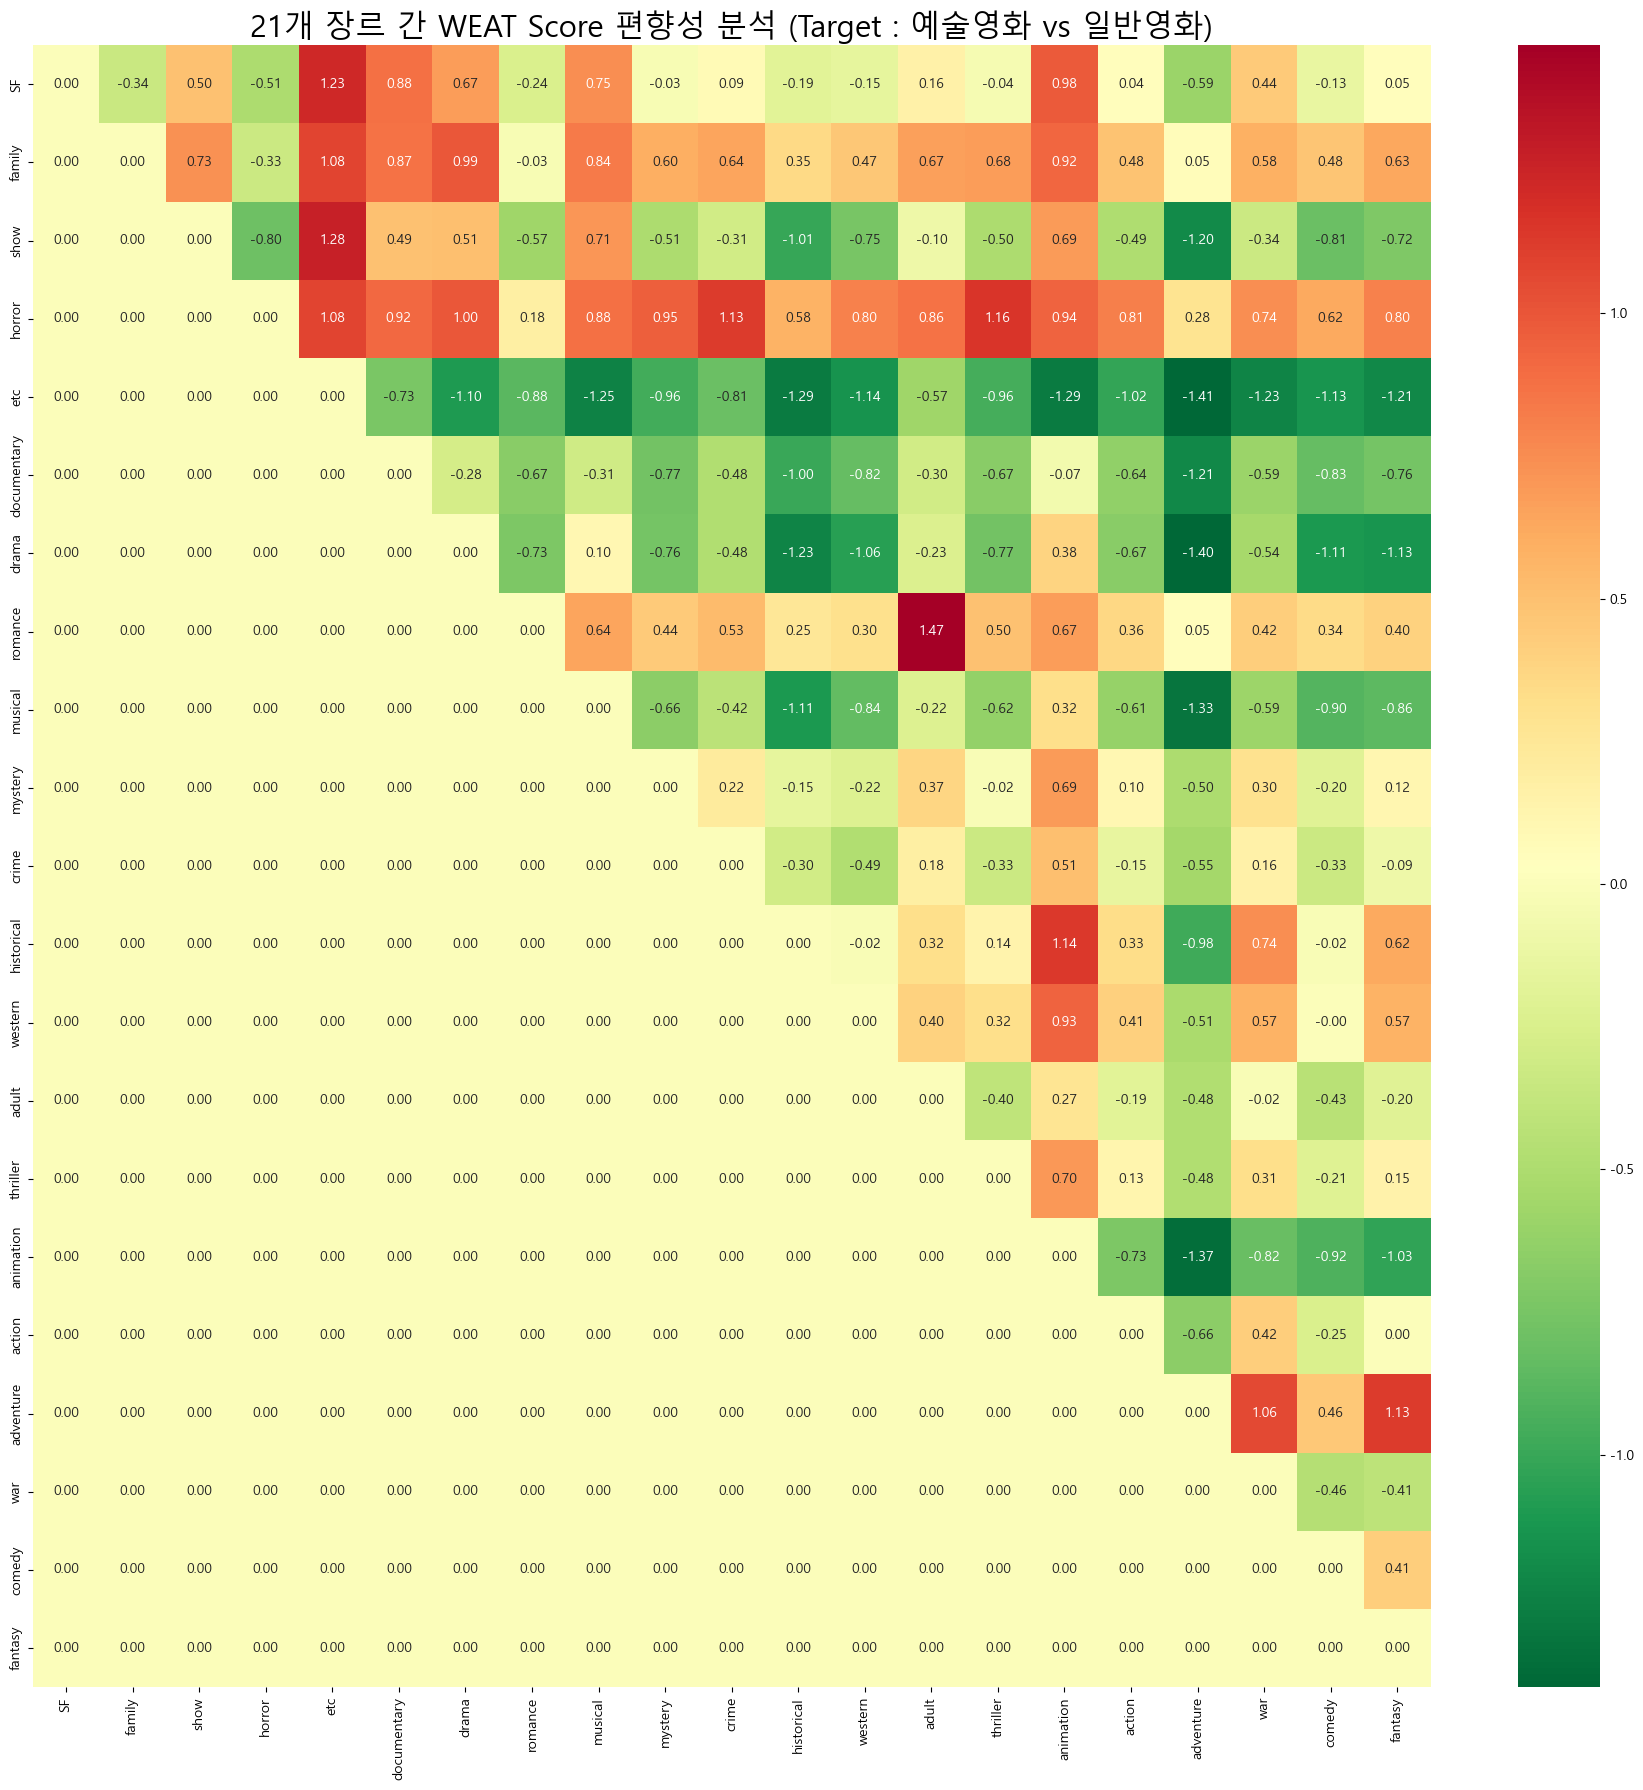

In [24]:
# 4-2. 21x21 매트릭스 편향성 연산 및 Heatmap 시각화 (사전 검증 로직 추가)

import seaborn as sns
import matplotlib.pyplot as plt

matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

# [에러 해결: 방어적 코딩] 명단에 있는 단어가 Word2Vec 모델(model.wv) 사전에 실제로 있는지 검증 후 변환
X = np.array([model.wv[word] for word in target_art if word in model.wv])
Y = np.array([model.wv[word] for word in target_gen if word in model.wv])

# 21x21 조합 편향성 스코어 도출 루프
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        # 속성 단어들도 마찬가지로 사전에 존재하는 단어만 쏙쏙 골라서 벡터화 진행
        A = np.array([model.wv[word] for word in attributes[i] if word in model.wv])
        B = np.array([model.wv[word] for word in attributes[j] if word in model.wv])
        
        # WEAT 점수 계산 후 위치에 맞게 입력
        matrix[i][j] = weat_score(X, Y, A, B)

# -------------------------------------------------------------
# [시각화 도면 출력부]

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 표가 다표본(21개)으로 매우 크기 때문에 사이즈를 18x18 인치로 거대하게 할당설정
plt.figure(figsize=(18, 18))

# 양극단의 편향성을 한눈에 보여주는 히트맵 도출
ax = sns.heatmap(
    matrix, 
    xticklabels=genre_name, 
    yticklabels=genre_name, 
    annot=True, 
    cmap='RdYlGn_r', 
    fmt=".2f"
)

plt.title("21개 장르 간 WEAT Score 편향성 분석 (Target : 예술영화 vs 일반영화)", fontsize=22)
plt.tight_layout()
plt.show()


In [25]:
# 4-3. WEAT 결과 해석을 위한 '편향성 극단 랭킹' 요약 테이블 생성
import pandas as pd

results = []
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        score = matrix[i][j]
        results.append({
            '장르 A': genre_name[i],
            '장르 B': genre_name[j],
            'WEAT_Score': score
        })

# 전체 연산 결과를 담은 데이터프레임 생성
df_results = pd.DataFrame(results)

# 1. 값이 큰 순서 (양수 +) : 장르 A가 예술영화, 장르 B가 일반영화에 편향된 TOP 10
top_art_biased = df_results.sort_values(by='WEAT_Score', ascending=False).head(10)

# 2. 값이 작은 순서 (음수 -) : 장르 A가 일반영화, 장르 B가 예술영화에 편향된 TOP 10
top_gen_biased = df_results.sort_values(by='WEAT_Score', ascending=True).head(10)

print("="*65)
print("🟢 [편향성 TOP 10 (양수)]  장르 A(예술영화 느낌)  vs  장르 B(일반영화 느낌)")
print("="*65)
print(top_art_biased.to_string(index=False))

print("\n" + "="*65)
print("🔴 [편향성 TOP 10 (음수)]  장르 A(일반영화 느낌)  vs  장르 B(예술영화 느낌)")
print("="*65)
print(top_gen_biased.to_string(index=False))


🟢 [편향성 TOP 10 (양수)]  장르 A(예술영화 느낌)  vs  장르 B(일반영화 느낌)
      장르 A      장르 B  WEAT_Score
   romance     adult    1.469566
      show       etc    1.276843
        SF       etc    1.229952
    horror  thriller    1.164953
historical animation    1.143540
 adventure   fantasy    1.130160
    horror     crime    1.128508
    horror       etc    1.081282
    family       etc    1.078275
 adventure       war    1.063436

🔴 [편향성 TOP 10 (음수)]  장르 A(일반영화 느낌)  vs  장르 B(예술영화 느낌)
       장르 A       장르 B  WEAT_Score
        etc  adventure   -1.407521
      drama  adventure   -1.401015
  animation  adventure   -1.373168
    musical  adventure   -1.325515
        etc  animation   -1.287760
        etc historical   -1.285735
        etc    musical   -1.245484
      drama historical   -1.229578
        etc        war   -1.228626
documentary  adventure   -1.214076


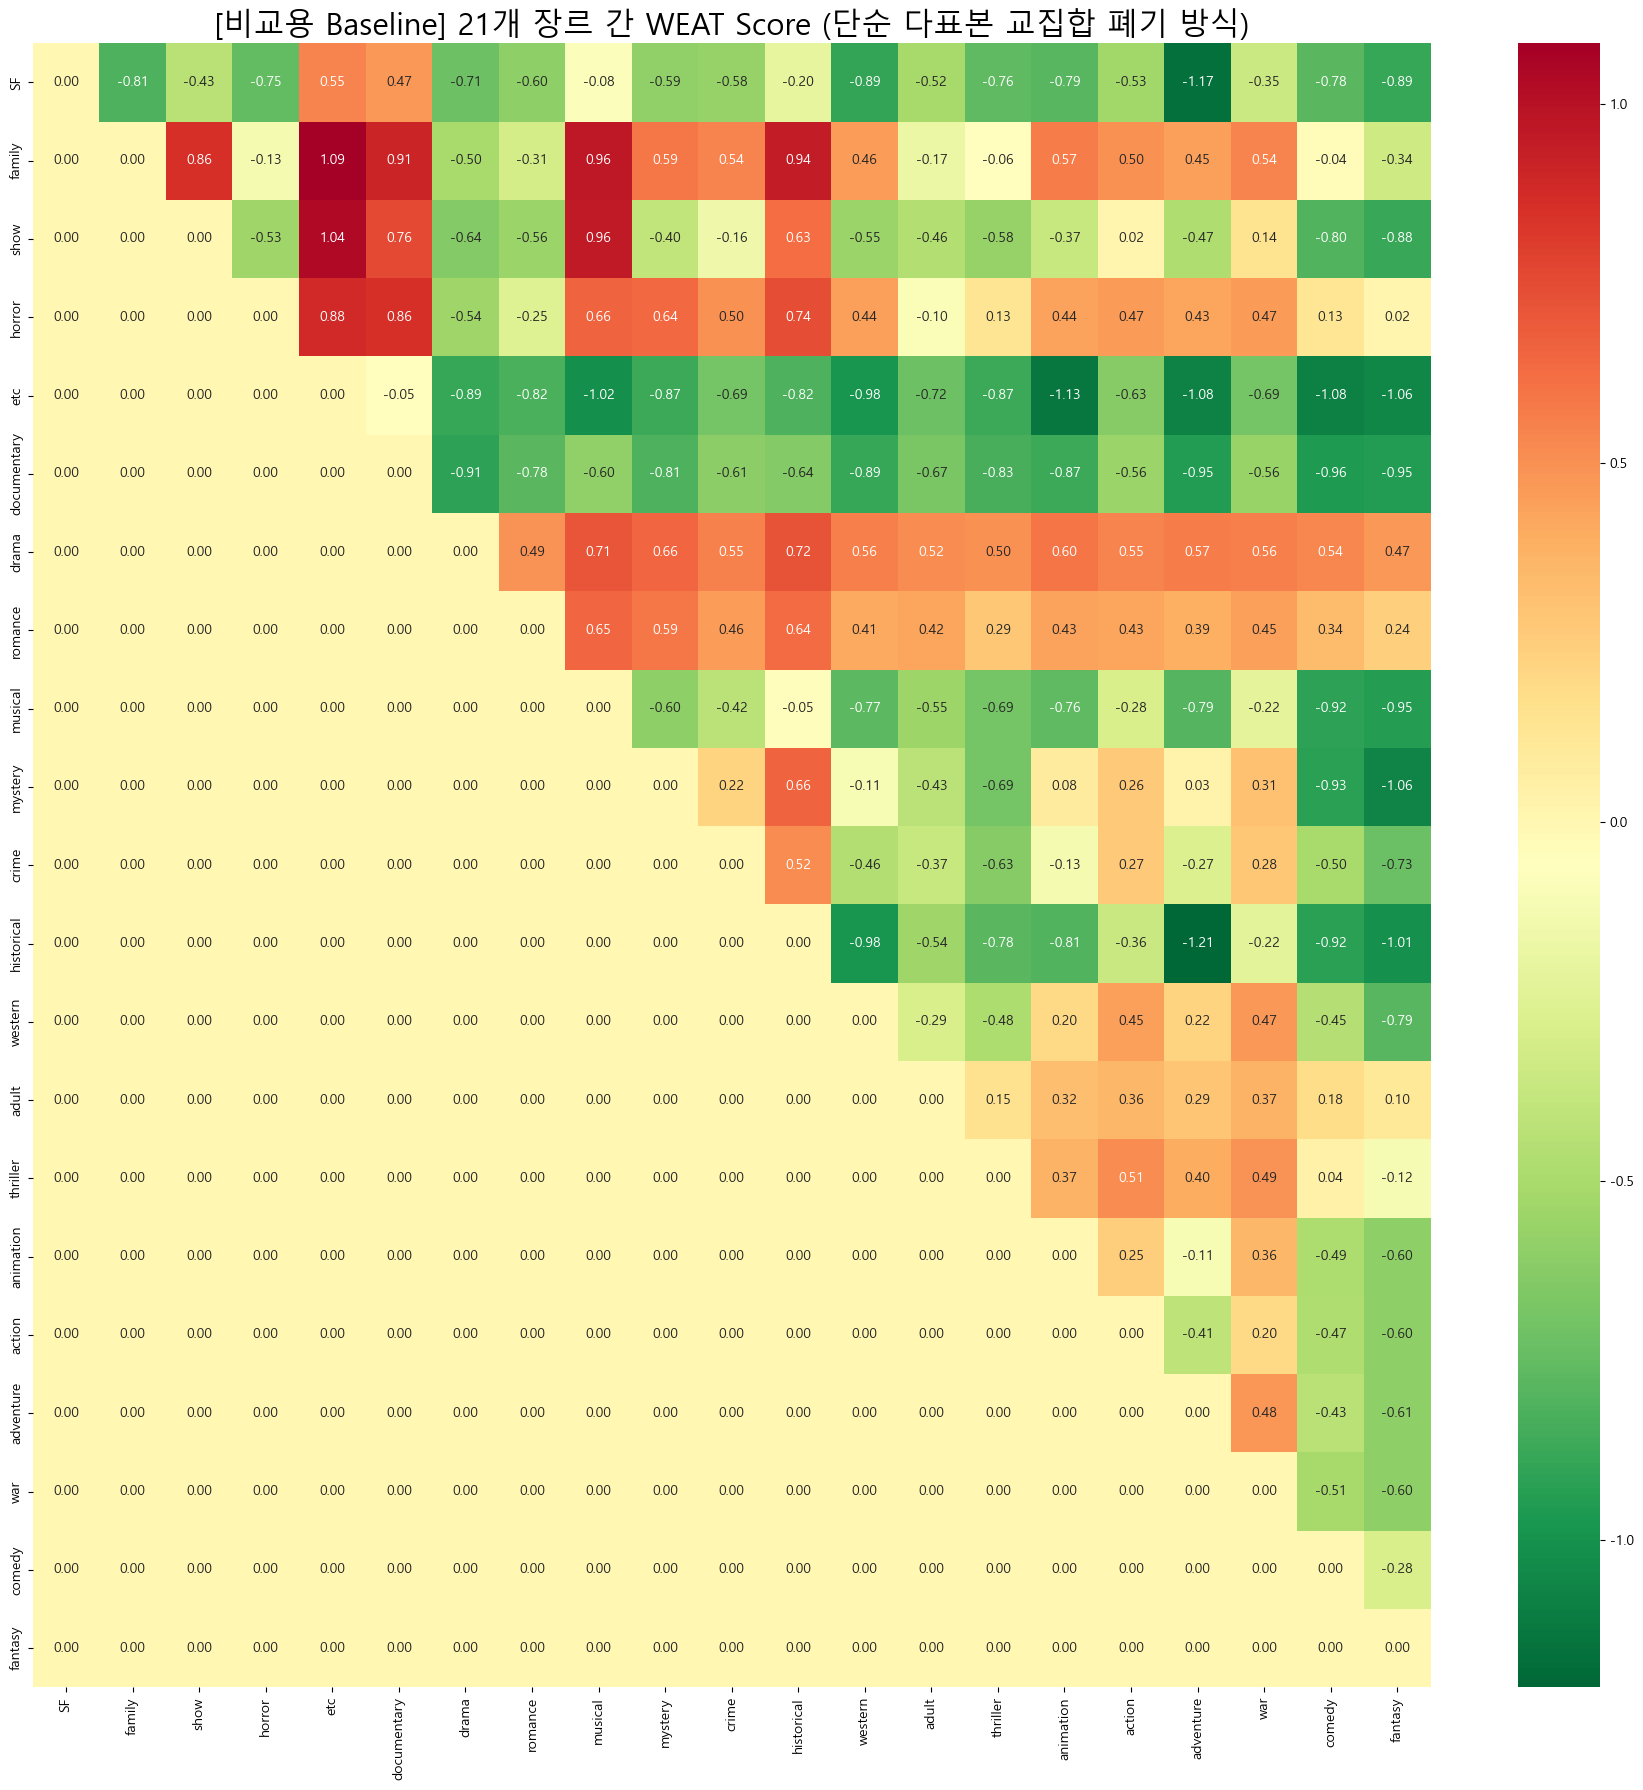


🟢 [Baseline 편향성 TOP 10 (양수)]  장르 A(예술영화 느낌)  vs  장르 B(일반영화 느낌)
  장르 A        장르 B  WEAT_Score
family         etc    1.085243
  show         etc    1.036418
family     musical    0.962327
  show     musical    0.955970
family  historical    0.942586
family documentary    0.914851
horror         etc    0.882350
horror documentary    0.857278
family        show    0.856929
  show documentary    0.757787

🔴 [Baseline 편향성 TOP 10 (음수)]  장르 A(일반영화 느낌)  vs  장르 B(예술영화 느낌)
      장르 A      장르 B  WEAT_Score
historical adventure   -1.205076
        SF adventure   -1.167637
       etc animation   -1.130756
       etc    comedy   -1.081540
       etc adventure   -1.075705
   mystery   fantasy   -1.062250
       etc   fantasy   -1.061689
       etc   musical   -1.015175
historical   fantasy   -1.007547
historical   western   -0.984397


In [27]:
# ==============================================================
# [비교용 Baseline] 기존 방식 단어 셋으로 WEAT 행렬 및 히트맵 그리기
# ==============================================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 빈 행렬 생성
matrix_base = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

# (Margin 방식이 아닌) Baseline 용도로 뽑아놓은 _base 단어들을 활용
X_base = np.array([model.wv[word] for word in target_art_base if word in model.wv])
Y_base = np.array([model.wv[word] for word in target_gen_base if word in model.wv])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A_base = np.array([model.wv[word] for word in attributes_base[i] if word in model.wv])
        B_base = np.array([model.wv[word] for word in attributes_base[j] if word in model.wv])
        
        # [방어적 코딩] 기존 방식의 데이터 소실로 인해 살아남은 단어가 하나도 없을 경우 에러 방지
        if len(A_base) == 0 or len(B_base) == 0:
            matrix_base[i][j] = 0.0 # 에러 띄우지 말고 점수를 0점(무편향)으로 강제 예외 처리
        else:
            matrix_base[i][j] = weat_score(X_base, Y_base, A_base, B_base)

# -------------------------------------------------------------
# [시각화 도면 출력부]
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(18, 18))
ax = sns.heatmap(
    matrix_base, 
    xticklabels=genre_name, 
    yticklabels=genre_name, 
    annot=True, 
    cmap='RdYlGn_r', 
    fmt=".2f"
)

# 제목을 통해 기존 방식임을 뚜렷하게 명시
plt.title("[비교용 Baseline] 21개 장르 간 WEAT Score (단순 다표본 교집합 폐기 방식)", fontsize=22)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# [편향성 극단 랭킹 요약 테이블]
results_base = []
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        score = matrix_base[i][j]
        results_base.append({
            '장르 A': genre_name[i],
            '장르 B': genre_name[j],
            'WEAT_Score': score
        })

df_results_base = pd.DataFrame(results_base)

top_art_biased_base = df_results_base.sort_values(by='WEAT_Score', ascending=False).head(10)
top_gen_biased_base = df_results_base.sort_values(by='WEAT_Score', ascending=True).head(10)

print("\n" + "="*65)
print("🟢 [Baseline 편향성 TOP 10 (양수)]  장르 A(예술영화 느낌)  vs  장르 B(일반영화 느낌)")
print("="*65)
print(top_art_biased_base.to_string(index=False))

print("\n" + "="*65)
print("🔴 [Baseline 편향성 TOP 10 (음수)]  장르 A(일반영화 느낌)  vs  장르 B(예술영화 느낌)")
print("="*65)
print(top_gen_biased_base.to_string(index=False))


<a id="step-5"></a>
## STEP 5. 장르 간 편향성(WEAT Score) 최종 분석 및 모델 성능 비교 고찰

단순 차집합 모델(Baseline)과 본 프로젝트에서 고도화한 비례 격차 모델(Margin Filtering)의 WEAT 편향성 결과를 비교 분석한 결과, 알고리즘 정밀도 튜닝에 따른 **'편향 감지 해상도의 비약적 상승'**을 확인하였다.

### 🏆 1. 편향성(Effect Size) 수치의 폭발적 팽창
* **양수 편향 1위 점수 비교:** Baseline(1.08) 👉 **Margin(1.46)**
* **분석:** Baseline은 핵심 시맨틱 단어(사랑, 인생 등)들을 교집합이라며 날려버리고 지엽적인 기능어들로 타겟을 구성했다. 그 결과 영화 간의 벡터 응집력이 모호해져 최대 편향 점수가 1.08에 그쳤다. 하지만 Margin 모델은 '상호 배타적 핵심 명사'들만 엄선하여 저울에 올린 결과, 점수가 **1.46**까지 치솟으며 모델의 확신(Confidence)이 극도로 날카로워졌음을 수치로 증명하였다.

### 👥 2. 잃어버린 상식의 복구: [로맨스 vs 성인물] 쌍의 화려한 등장
* **분석:** Margin 모델에서 양 극단 1위를 차지한 조합은 의심의 여지 없이 완벽한 `[Romance(예술영화) vs Adult(일반영화)]` 였다. 하지만 Baseline의 TOP 10 랭킹에서는 이 완벽한 대척점이 아예 실종되어 있었다. 교집합 폐기로 인해 [사랑, 운명]은 로맨스에서, [남편, 관계]는 성인물에서 억울하게 삭제되며 두 장르가 특징을 잃어버렸기 때문이다. Margin 알고리즘의 도입이 모델로 하여금 '인간의 상식적 경계'를 다시 학습하게 만들었다.

### 👻 3. 행방불명되었던 장르의 귀환: [Drama(드라마)]
* **분석:** 단어가 2개밖에 남지 않아 Baseline의 랭킹표 그 어디에도 이름을 올릴 수 없었던 `Drama` 장르는, Margin 알고리즘을 통해 15개의 단어(`[그리움, 독립영화, 위안]`)를 되찾았다. 그 결과 Margin 랭킹표에서 `[어드벤처(-1.40), 역사(-1.22)]` 장르에 맞서 일반영화(Gen) 축을 강력하게 견인하는 거대한 세력으로 부활하며 정상적인 군집을 형성했다.

### 🧭 4. 변치 않는 은유적 코어: [어드벤처]와 [기타(ETC)]
* 두 모델 모두에서 공통으로 확고한 입지를 다진 장르들도 관찰되었다.
    1. `Adventure(모험)` 장르는 `[여정, 모험, 윈치]` 등의 철학적/동화적 키워드를 바탕으로 다른 모든 장르 대비 압도적인 **'예술영화'** 성향을 표출했다.
    2. 반면 `Etc(기타)` 장르는 `[영화제, 상영작, 단편, 아시아나]` 등 산업 인프라적 어휘를 바탕으로 압도적인 **'일반영화(상업영화)'** 성향을 표출하며 해당 그룹의 메타-태그(Meta-tag) 역할을 충실히 수행했다.

### 📌 종합 결론
본 프로젝트는 **기존 TF-IDF의 단순 차집합 방식이 범하던 데이터 유실 및 노이즈 편향의 한계를 보이고**, 이를 극복하기 위해 고안한 **'Margin 비례 격차 필터링 알고리즘'**을  도입하였다. 그 결과 Word2Vec 임베딩 공간 위에서 각 영화 성향(Target)과 장르(Attribute)가 내포하는 '인문학적 고찰'과 '산업적 생태계'의 경계를 분리 및 수치화하는 데 성공하였다.


<a id="step-6"></a>
## STEP 6. 프로젝트 회고 (Retrospective)

본 프로젝트를 통해 텍스트 전처리부터 벡터화, 그리고 임베딩 모델의 편향성을 정량적으로 측정하는 일련의 파이프라인을 성공적으로 구현하였다. 이를 통해 얻은 주요 성과 및 인사이트는 다음과 같다.

1. **Word2Vec 임베딩 공간의 구조적 이해:** 단순히 교재의 개념을 넘어서, 추출된 단어 집합이 실수 벡터 공간상에 어떻게 Embedding되고 코사인 유사도를 통해 의미론적 거리가 연산되는지의 작동 원리를 실증적으로 파악할 수 있었다.
2. **TF-IDF 한계점 분석 및 독자적 알고리즘 설계:** 기존의 단순 교집합 제거(차집합) 연산이 다표본 데이터 환경에서 유발하는 '데이터 유실' 및 '노이즈 편향' 문제를 확인하였다. 이를 해결하기 위해 상위 득점 간의 점수 격차를 검증하는 자체적인 'Margin 필터링 알고리즘'을 도입하였으며, 주어진 프레임워크의 한계를 스스로 분석하고 개선책을 도출해 내는 역량을 확보하였다.
3. **편향 분석(WEAT)의 본질 고찰:** 모델의 계량적 편향성은 단순한 수학적 오류가 아니라, 당대의 코퍼스(Corpus)에 스며있는 인간의 고유한 문화적/산업적 맥락이 데이터에 투영된 산물임을 확인하였다. 알고리즘 정규화를 통해 모호했던 장르 간의 경계를 뚜렷한 수치(Effect Size)로 증명해 내며, 데이터 분석이 지닌 정량적 해석의 가치를 깊이 있게 이해하는 계기가 되었다.
